In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
import folium as fl
from selenium import webdriver
from tqdm import tqdm_notebook as tqdmn
from selenium.webdriver.common.by import By
import csv
import json
import datetime as dt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import stats


In [4]:
df = pd.read_csv('data\drom_archive_2018-2023.csv')
pd.set_option('display.max_columns', None)
df

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\555455455.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('data\drom_archive_2018-2023.csv')
C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\555455455.py:1: DtypeWarning: Columns (6,13,16,17,18,19,20,21,22,23,28,29,30,31,33,34,35,36,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\drom_archive_2018-2023.csv')


,Название машины,Год,Ссылка,Дата размещения объявления,Цена,Кол-во просмотров,Скрыто,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,Рестайлинг,Цвет,Комплектация,Владелец,Особые отметки,Тип кузова,VIN,Проверено,Номер кузова,Метка,Город,Регион,Макро-регион,Грузоподъемность,Категория ТС,Длина кузова,Тип техники,Количество мест,Масса,Количество осей,Объем кузова,Тип кабины,Рефрижератор,Топливо,Спальник,Колёсная формула
0,BMW X6,2017,https://auto.drom.ru/surgut/bmw/x6/29345346.html,2018-03-29,4630000.0,1188.0,1.0,3.0,дизель,313.0,АКПП,4WD,0.0,левый,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bmw,Сургут,Ханты-Мансийский автономный округ,УрФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BMW X6,2017,https://auto.drom.ru/barnaul/bmw/x6/28319308.html,2018-04-09,4310000.0,1259.0,0.0,3.0,бензин,306.0,АКПП,4WD,0.0,левый,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bmw,Барнаул,Алтайский край,СФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BMW X6,2017,https://auto.drom.ru/rostov-na-donu/bmw/x6/294...,2018-04-12,4450000.0,528.0,0.0,3.0,дизель,249.0,АКПП,4WD,1500.0,левый,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bmw,Ростов-на-Дону,Ростовская область,ЮФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BMW X6,2017,https://auto.drom.ru/novosibirsk/bmw/x6/266481...,2018-04-13,5270000.0,1200.0,1.0,3.0,дизель,249.0,АКПП,4WD,0.0,левый,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bmw,Новосибирск,Новосибирская область,Новосибирск,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BMW X6,2017,https://auto.drom.ru/barnaul/bmw/x6/29113964.html,2018-04-18,4690000.0,888.0,1.0,3.0,дизель,313.0,АКПП,4WD,0.0,левый,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bmw,Барнаул,Алтайский край,СФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5397164,Ford Explorer,2008,https://auto.drom.ru/zheleznogorsk-krasnoyarsk...,2019-04-16,850000.0,1055.0,1.0,4.6,бензин,292.0,АКПП,4WD,93456.0,левый,4.0,0.0,черный,4.6 AT 4WD EDDIE BAUER 7-passenger,Частное лицо6 лет на Дроме,NaN,джип/suv 5 дв.,NaN,NaN,NaN,ford,Железногорск,Красноярский край,СФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397165,Toyota Vitz,2010,https://auto.drom.ru/zheleznogorsk-krasnoyarsk...,2021-07-09,429000.0,323.0,1.0,1.0,бензин,71.0,вариатор,передний,109500.0,правый,2.0,0.0,бордовый,1.0 B S edition,Частное лицоБолее 10 лет на Дроме,NaN,хэтчбек 5 дв.,NaN,NaN,NaN,toyota,Железногорск,Красноярский край,СФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397166,Toyota Sprinter Marino,1992,https://auto.drom.ru/zima/toyota/sprinter_mari...,2021-04-04,93000.0,1221.0,1.0,1.6,бензин,115.0,АКПП,передний,NaN,правый,1.0,0.0,красный,NaN,Собственник3 года на Дроме,NaN,NaN,NaN,NaN,NaN,toyota,Зима,Иркутская область,СФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397167,Toyota Wish,2005,https://auto.drom.ru/zmeinogorsk/toyota/wish/3...,2019-04-20,480000.0,1195.0,0.0,1.8,бензин,132.0,АКПП,передний,170000.0,правый,1.0,0.0,серый,NaN,Частное лицо5 лет на Дроме,NaN,NaN,NaN,NaN,NaN,toyota,Змеиногорск,Республика Алтай,СФО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5397169 entries, 0 to 5397168
Data columns (total 41 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Название машины             object 
 1   Год                         int64  
 2   Ссылка                      object 
 3   Дата размещения объявления  object 
 4   Цена                        float64
 5   Кол-во просмотров           float64
 6   Скрыто                      object 
 7   Объем двигателя             float64
 8   Тип двигателя               object 
 9   Мощность                    float64
 10  Коробка передач             object 
 11  Привод                      object 
 12  Пробег                      float64
 13  Руль                        object 
 14  Поколение                   float64
 15  Рестайлинг                  float64
 16  Цвет                        object 
 17  Комплектация                object 
 18  Владелец                    object 
 19  Особые отметки       

Очистка данных

Удаление столбцов, которые не содержат полезных данных

In [6]:
df = df.drop(columns=["Тип кузова", "VIN", "Номер кузова", "Грузоподъемность", "Категория ТС", "Длина кузова", "Тип техники", "Количество мест",
                      "Масса", "Количество осей", "Объем кузова", "Тип кабины", "Рефрижератор", "Топливо", "Спальник", "Колёсная формула", "Проверено"])

In [7]:
df['Дата размещения объявления'] = pd.to_datetime(df['Дата размещения объявления'])

In [8]:
df['Особые отметки'].fillna('Нет', inplace=True)

C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\636554373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Особые отметки'].fillna('Нет', inplace=True)


**Цель**: Выявить 5 самых продаваемых автомобилей

In [9]:
most_resale_percent = df['Название машины'].value_counts(normalize=True)[:5]

In [10]:
most_resale = (df['Название машины'].value_counts()[:5]) // 1000

В численном формате:

C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\3529403702.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(most_resale, palette= ['green'] + ['lightgreen'] * 4)


<Axes: xlabel='Марка и модель автомобиля', ylabel='Количество объявлений, тыс.'>

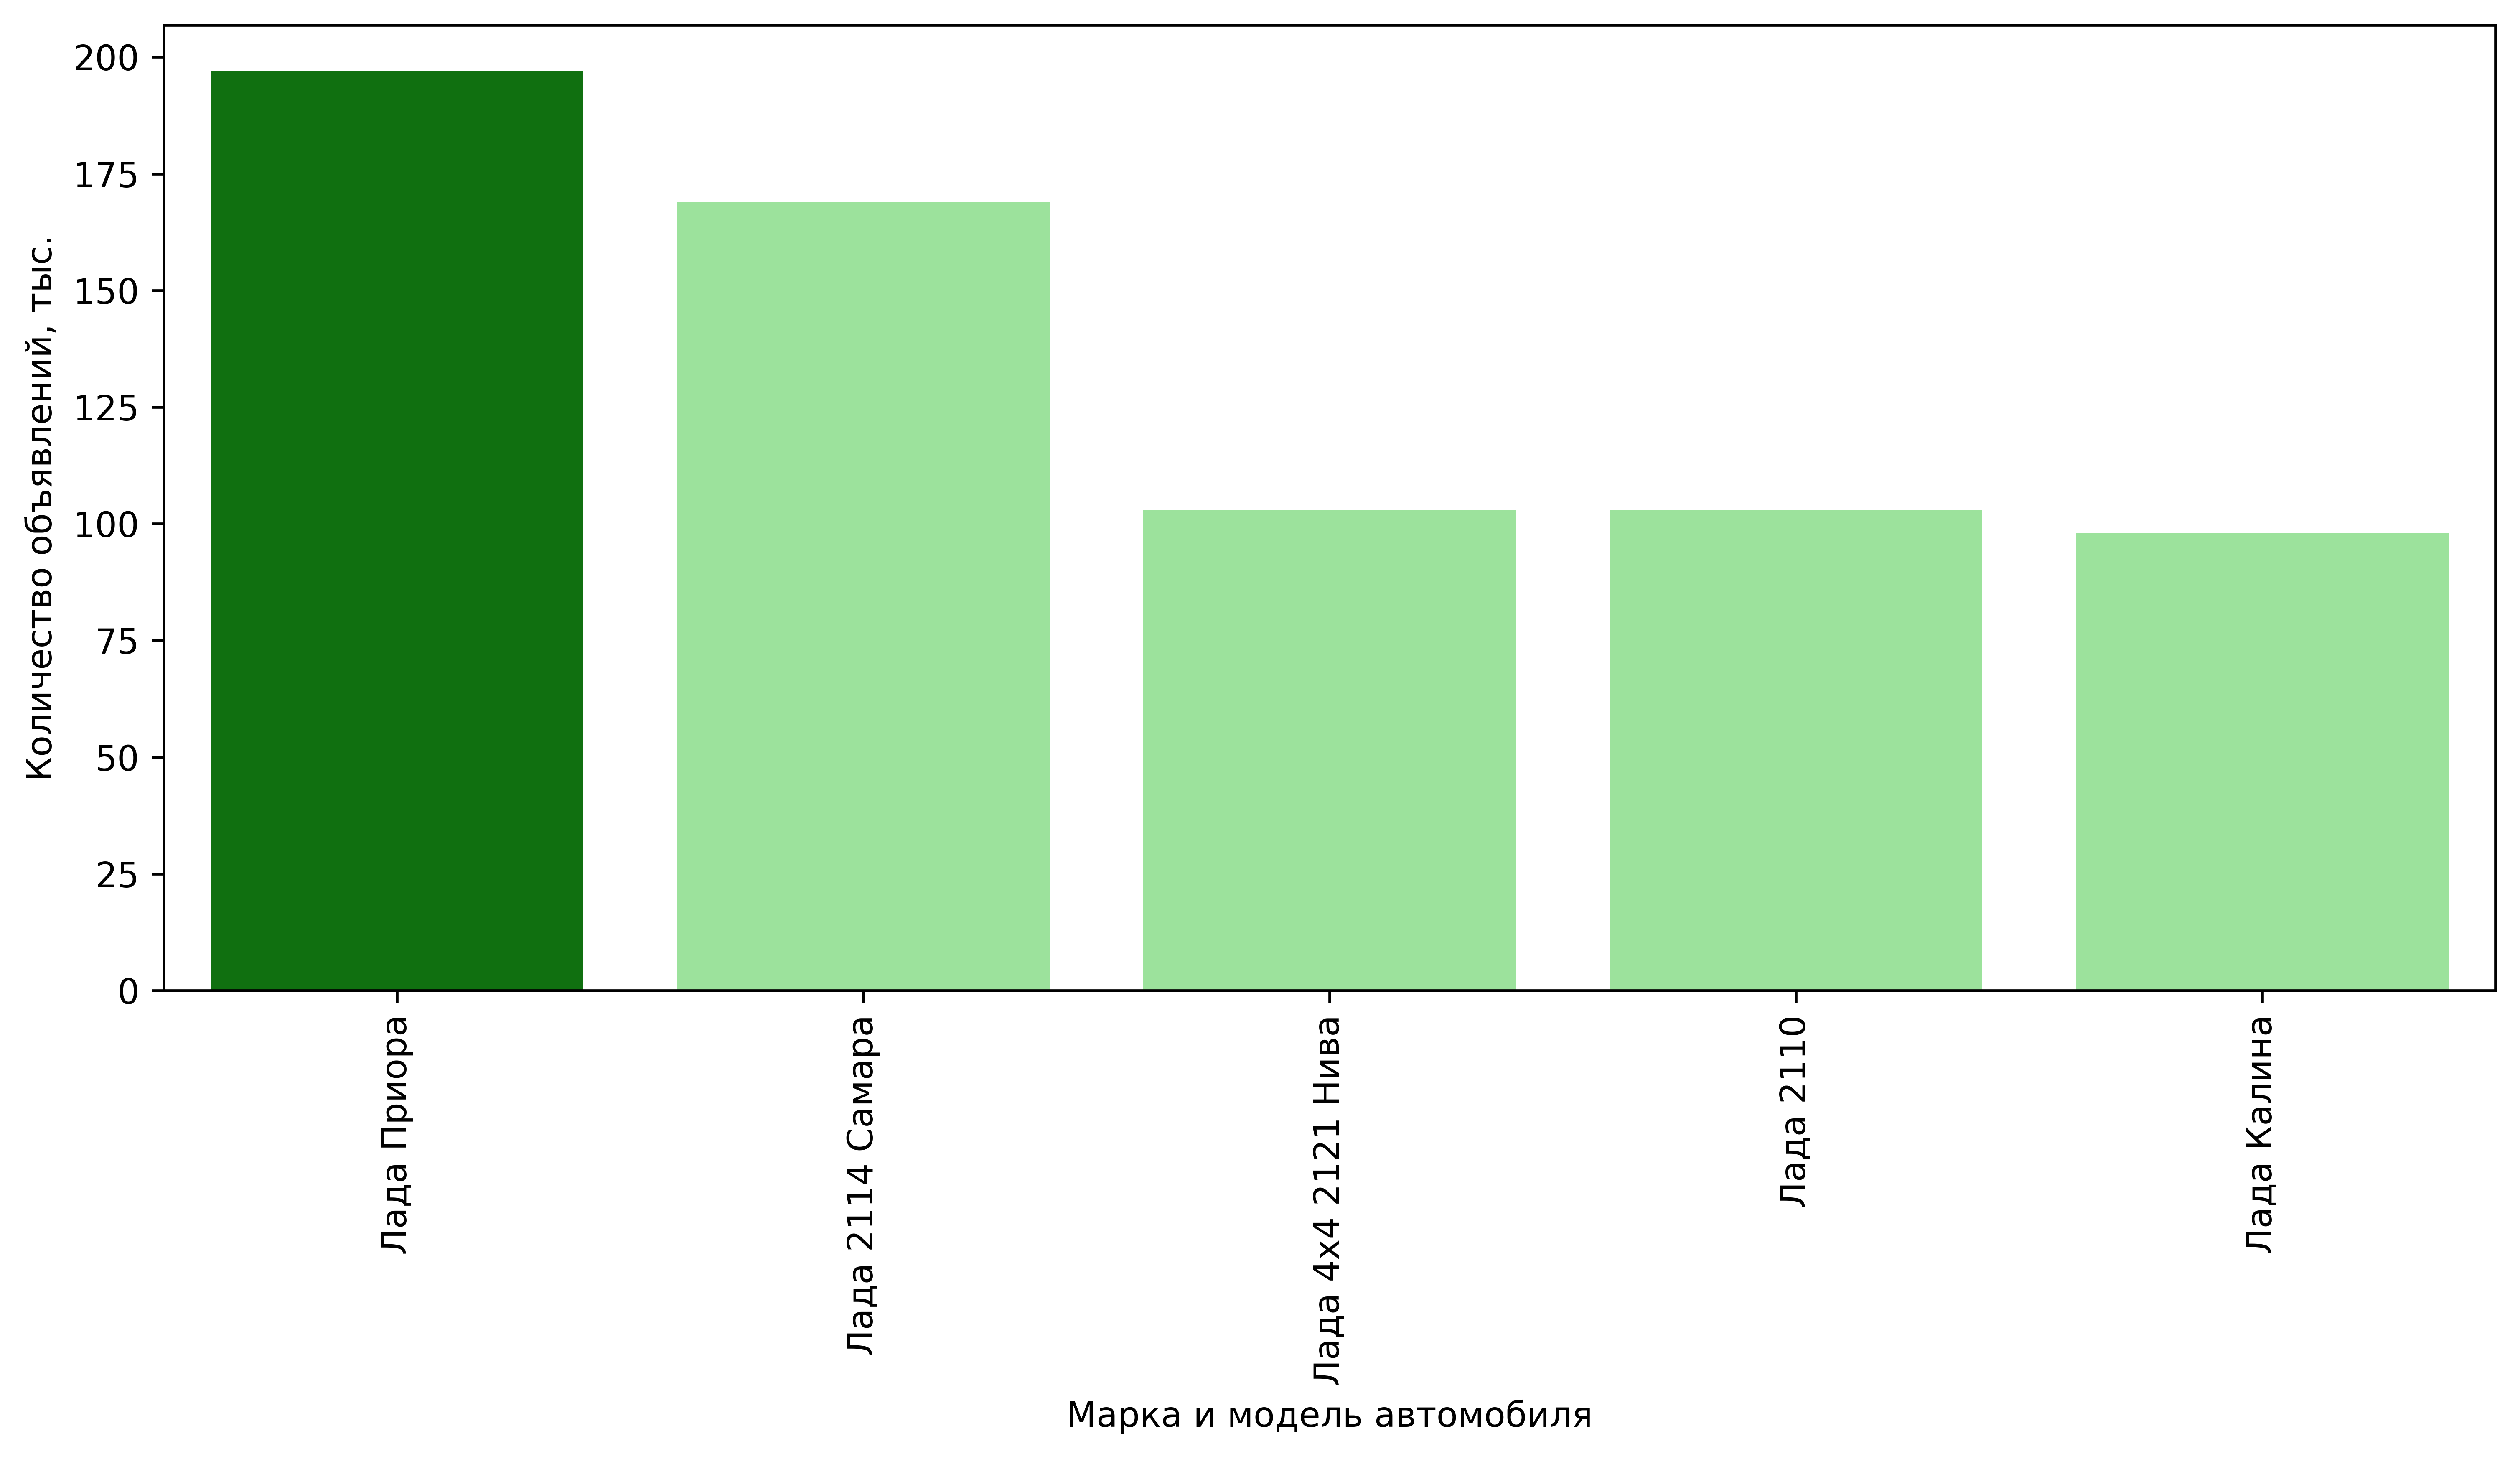

In [11]:
plt.figure(figsize=(12, 5), dpi= 600)
plt.xticks(rotation=90)
plt.ylabel('Количество объявлений, тыс.')
plt.xlabel('Марка и модель автомобиля')
sns.barplot(most_resale, palette= ['green'] + ['lightgreen'] * 4)

В процентах относительно общего количества продаж:

C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\3749685062.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(most_resale_percent, palette= ['green'] + ['lightgreen'] * 4);


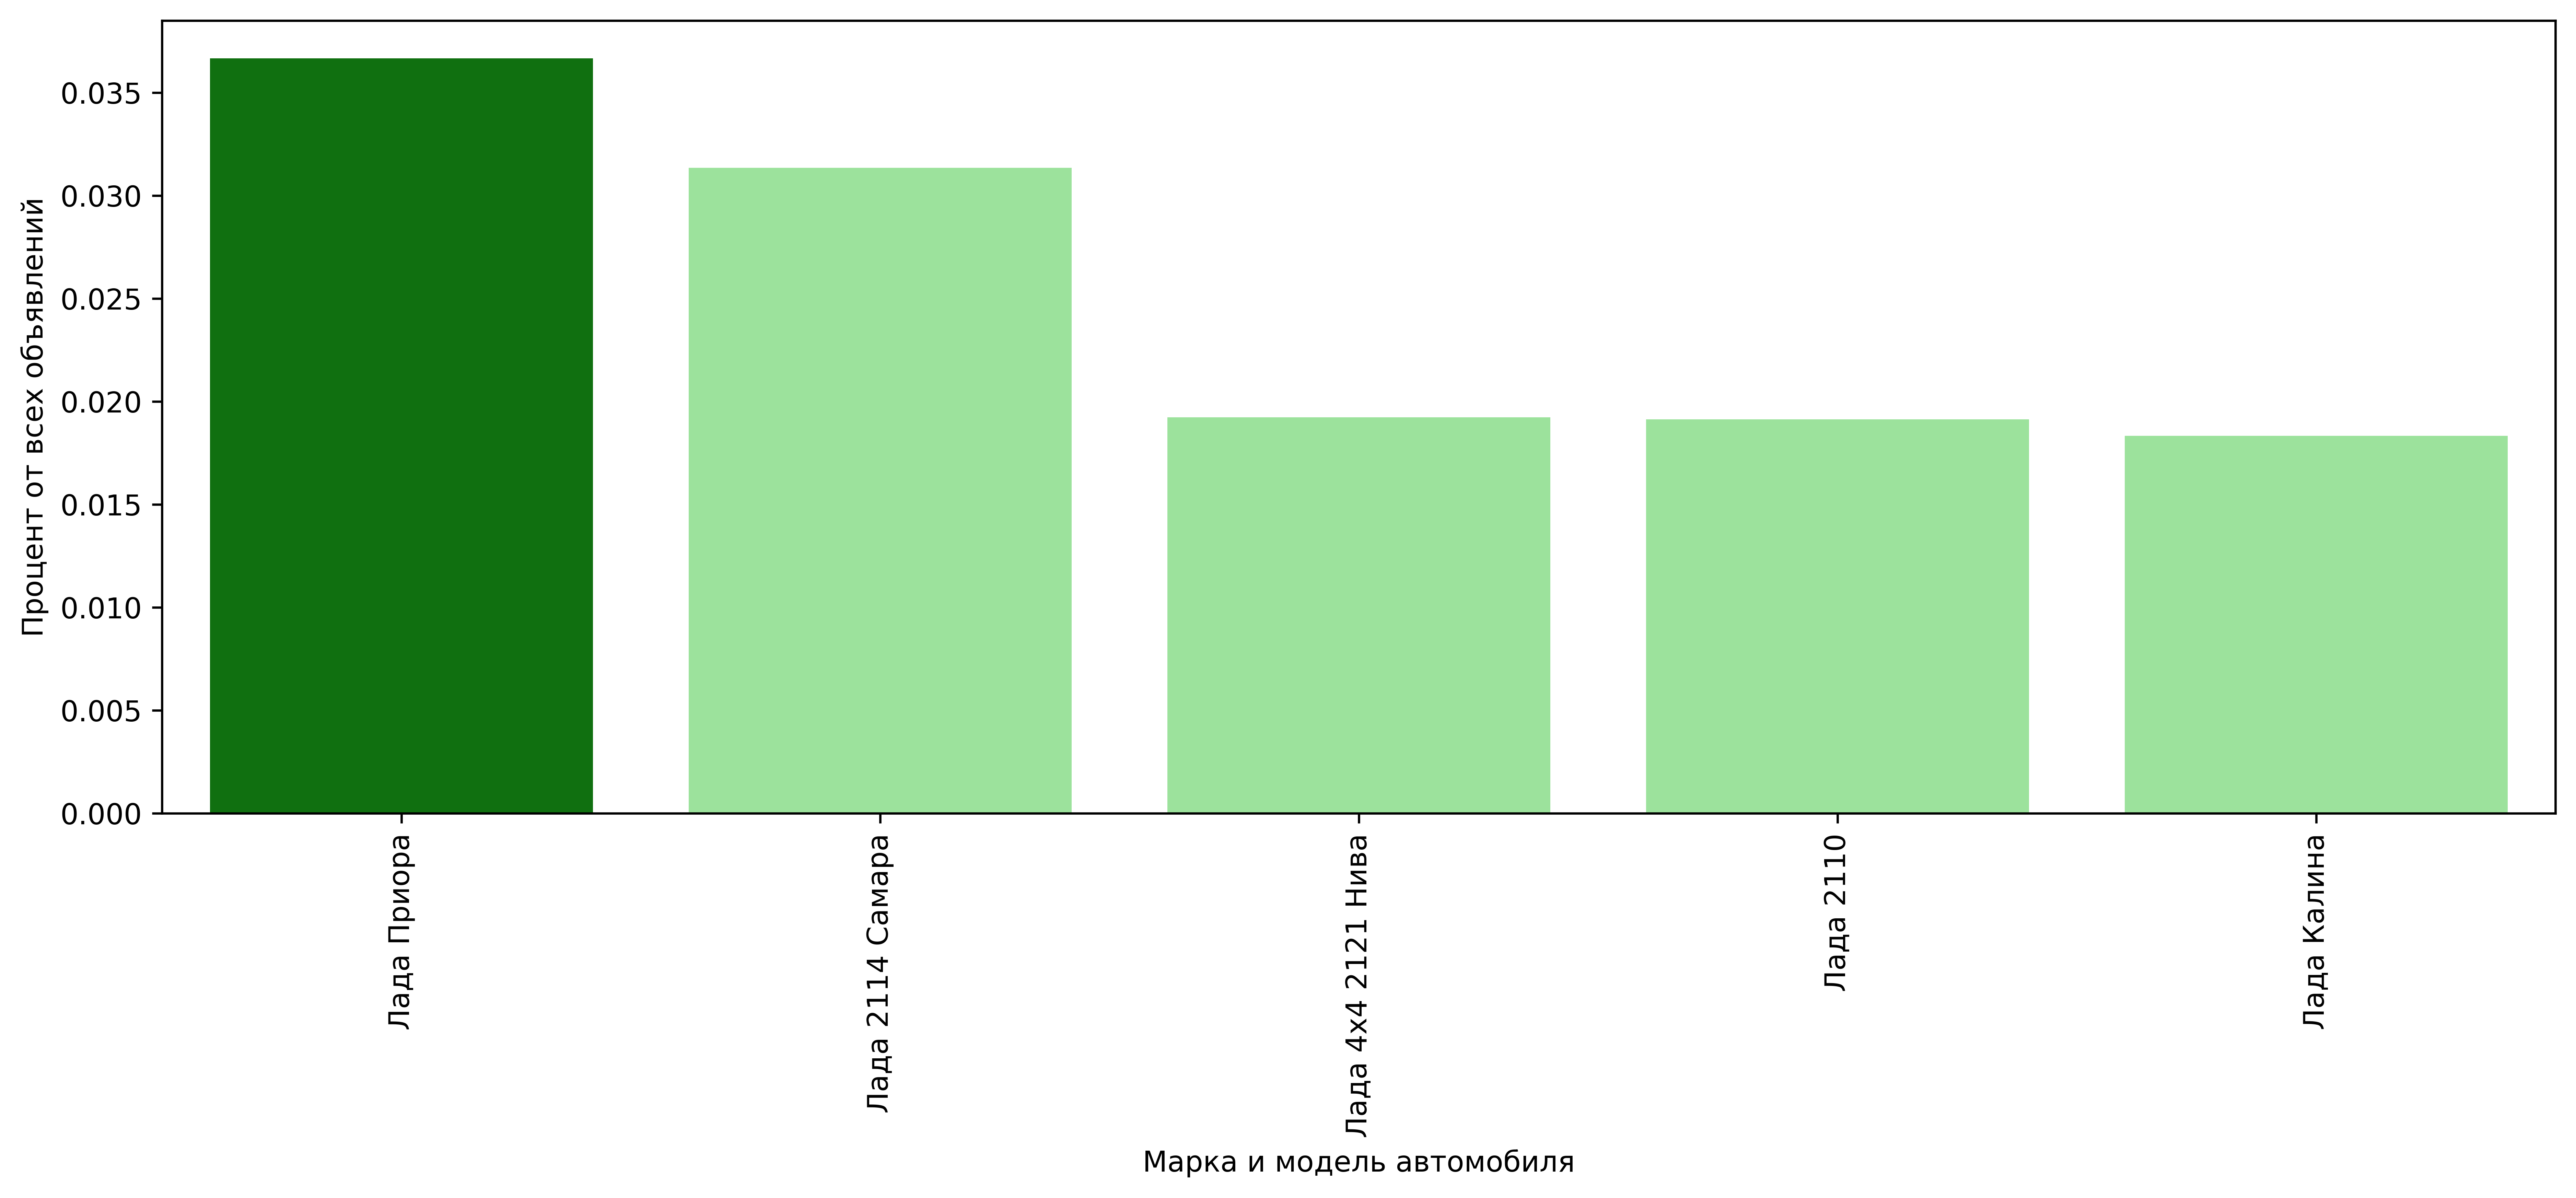

In [12]:
plt.figure(figsize=(15, 5), dpi= 600)
plt.xticks(rotation=90)
plt.ylabel('Процент от всех объявлений')
plt.xlabel('Марка и модель автомобиля')
sns.barplot(most_resale_percent, palette= ['green'] + ['lightgreen'] * 4);

**Вывод**: Самый продаваемый автомобиль по России - Лада Приора. Процент Лады Приоры от общего количества продаж - более 3.5 процентов, что в числах - около 200 тысяч объявлений. Это может быть связано с тем, что Лада Приора - отечественный автомобиль, который в своем ценовом сегменте имеет ряд преимуществ над конкурентами.

In [13]:
df1 = df.copy()
df1 = df1[df1['Название машины'] == 'Лада Приора']
df1

,Название машины,Год,Ссылка,Дата размещения объявления,Цена,Кол-во просмотров,Скрыто,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,Рестайлинг,Цвет,Комплектация,Владелец,Особые отметки,Метка,Город,Регион,Макро-регион
3445731,Лада Приора,2013,https://auto.drom.ru/abakan/lada/priora/462212...,2022-08-02,390000.0,540.0,1.0,1.6,бензин,98.0,механика,передний,160000.0,левый,1.0,0.0,коричневый,1.6 MT Люкс 21703-33-046,Собственник3 года на Дроме,Нет,lada,Абакан,Республика Хакасия,СФО
3445737,Лада Приора,2013,https://auto.drom.ru/aktanish/lada/priora/4930...,2022-12-20,410000.0,138.0,1.0,1.6,бензин,98.0,механика,передний,119190.0,левый,1.0,0.0,коричневый,1.6 MT Люкс 21703-33-046,Частное лицо4 года на Дроме,Нет,lada,Актаныш,Республика Татарстан,ПФО
3445738,Лада Приора,2013,https://auto.drom.ru/alhan-kala/lada/priora/49...,2022-12-14,390000.0,44.0,1.0,1.6,бензин,98.0,механика,передний,207000.0,левый,1.0,0.0,коричневый,NaN,Частное лицо2 года на Дроме,Нет,lada,Алхан-Кала,Чеченская Республика,СКФО
3445740,Лада Приора,2013,https://auto.drom.ru/almetievsk/lada/priora/52...,2023-09-05,420000.0,127.0,1.0,1.6,бензин,98.0,механика,передний,130562.0,левый,1.0,0.0,коричневый,1.6 MT Норма 21703-31-043,Частное лицо1 год на Дроме,Нет,lada,Альметьевск,Республика Татарстан,ПФО
3445762,Лада Приора,2013,https://auto.drom.ru/argun/lada/priora/5313574...,2023-10-25,470000.0,72.0,1.0,1.6,бензин,98.0,механика,передний,NaN,левый,1.0,0.0,коричневый,NaN,Частное лицо1 год на Дроме,Нет,lada,Аргун,Чеченская Республика,СКФО
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5390430,Лада Приора,2011,https://auto.drom.ru/votkinsk/lada/priora/4893...,2022-11-15,220000.0,50.0,1.0,1.6,бензин,98.0,механика,передний,97387.0,левый,1.0,0.0,черный,NaN,Фирма,Нет,lada,Воткинск,Удмуртская Республика,ПФО
5390437,Лада Приора,2013,https://auto.drom.ru/yaroslavl/lada/priora/347...,2019-07-21,277000.0,506.0,0.0,1.6,бензин,98.0,механика,передний,135000.0,левый,1.0,0.0,черный,NaN,Частное лицо5 лет на Дроме,Нет,lada,Ярославль,Кировская область,ПФО
5390441,Лада Приора,2010,https://auto.drom.ru/zheleznogorsk-krasnoyarsk...,2018-02-06,250000.0,395.0,1.0,1.6,бензин,98.0,механика,передний,125000.0,левый,1.0,0.0,серый,NaN,Частное лицо7 лет на Дроме,Нет,lada,Железногорск,Красноярский край,СФО
5390444,Лада Приора,2009,https://auto.drom.ru/zlatoust/lada/priora/2896...,2018-04-16,215000.0,645.0,1.0,1.6,бензин,98.0,механика,передний,100000.0,левый,1.0,0.0,зеленый,1.6 MT Люкс 21723-83-039,Частное лицоБолее 10 лет на Дроме,Нет,lada,Златоуст,Челябинская область,УрФО


In [14]:
df1['Особые отметки'].fillna('Нет', inplace=True)

C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\149407724.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Особые отметки'].fillna('Нет', inplace=True)


In [15]:
px.box(df1[(df1['Особые отметки'] == 'Нет')]['Цена'])

Данный график собран по всей выборке, ниже - за 2023 год

In [16]:
px.box(df1[(df1['Дата размещения объявления'].dt.year == 2023) & (df1['Особые отметки'] == 'Нет')]['Цена'])

Из боксплота мы видим, что медианная цена - 299 тысяч рублей, всего 25 процентов рынка имеют стоимость более 370 тысяч рублей. Также мы видим огромное количество выбросов, которые имеют право на существование, так как в автомобиль может быть вложено большое количество денег, его состояние может отличаться от заводского(поменян двигатель, проведено его усовершенствование, изменен салон, поставлена сигнализация и тд.) Стоит отметить, что в данной выборке автомобили берутся только целые.

In [17]:
px.scatter(df1.groupby(df1['Дата размещения объявления'].dt.year).agg({'Цена':'median'}))

Видно, что с 2021 по 2022 медианная стоимость значительно выросла(с 220 тысяч рублей до 255 тысяч рублей), а с 2022 по 2023 с 255 тысыч рублей, по 290 тысяч рублей. Давайте посмотрим этот диапазон по месяцам.

In [18]:
df_l = df1[df1['Дата размещения объявления'].dt.year >= 2020]
df_l['new_date'] = df['Дата размещения объявления'].dt.strftime('%Y-%m')
df_l


C:\Users\kpuck\AppData\Local\Temp\ipykernel_12480\1839112524.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Название машины,Год,Ссылка,Дата размещения объявления,Цена,Кол-во просмотров,Скрыто,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,Рестайлинг,Цвет,Комплектация,Владелец,Особые отметки,Метка,Город,Регион,Макро-регион,new_date
3445731,Лада Приора,2013,https://auto.drom.ru/abakan/lada/priora/462212...,2022-08-02,390000.0,540.0,1.0,1.6,бензин,98.0,механика,передний,160000.0,левый,1.0,0.0,коричневый,1.6 MT Люкс 21703-33-046,Собственник3 года на Дроме,Нет,lada,Абакан,Республика Хакасия,СФО,2022-08
3445737,Лада Приора,2013,https://auto.drom.ru/aktanish/lada/priora/4930...,2022-12-20,410000.0,138.0,1.0,1.6,бензин,98.0,механика,передний,119190.0,левый,1.0,0.0,коричневый,1.6 MT Люкс 21703-33-046,Частное лицо4 года на Дроме,Нет,lada,Актаныш,Республика Татарстан,ПФО,2022-12
3445738,Лада Приора,2013,https://auto.drom.ru/alhan-kala/lada/priora/49...,2022-12-14,390000.0,44.0,1.0,1.6,бензин,98.0,механика,передний,207000.0,левый,1.0,0.0,коричневый,NaN,Частное лицо2 года на Дроме,Нет,lada,Алхан-Кала,Чеченская Республика,СКФО,2022-12
3445740,Лада Приора,2013,https://auto.drom.ru/almetievsk/lada/priora/52...,2023-09-05,420000.0,127.0,1.0,1.6,бензин,98.0,механика,передний,130562.0,левый,1.0,0.0,коричневый,1.6 MT Норма 21703-31-043,Частное лицо1 год на Дроме,Нет,lada,Альметьевск,Республика Татарстан,ПФО,2023-09
3445762,Лада Приора,2013,https://auto.drom.ru/argun/lada/priora/5313574...,2023-10-25,470000.0,72.0,1.0,1.6,бензин,98.0,механика,передний,NaN,левый,1.0,0.0,коричневый,NaN,Частное лицо1 год на Дроме,Нет,lada,Аргун,Чеченская Республика,СКФО,2023-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5390406,Лада Приора,2008,https://auto.drom.ru/uzhur/lada/priora/4322035...,2021-07-08,179000.0,1066.0,1.0,1.6,бензин,98.0,механика,передний,219163.0,левый,1.0,0.0,серебристый,1.6 MT Люкс 21723-03-033,Частное лицо4 года на Дроме,Нет,lada,Ужур,Красноярский край,СФО,2021-07
5390407,Лада Приора,2011,https://auto.drom.ru/velikovechnoe/lada/priora...,2020-05-14,220000.0,646.0,0.0,1.6,бензин,98.0,механика,передний,190000.0,левый,1.0,0.0,белый,NaN,Частное лицо8 лет на Дроме,Нет,lada,Великовечное,Краснодарский край,ЮФО,2020-05
5390410,Лада Приора,2011,https://auto.drom.ru/verhnyaya-pyshma/lada/pri...,2021-09-09,260000.0,379.0,1.0,1.6,бензин,98.0,механика,передний,97667.0,левый,1.0,0.0,черный,NaN,Собственник3 года на Дроме,Нет,lada,Верхняя Пышма,Свердловская область,УрФО,2021-09
5390430,Лада Приора,2011,https://auto.drom.ru/votkinsk/lada/priora/4893...,2022-11-15,220000.0,50.0,1.0,1.6,бензин,98.0,механика,передний,97387.0,левый,1.0,0.0,черный,NaN,Фирма,Нет,lada,Воткинск,Удмуртская Республика,ПФО,2022-11


In [23]:
for i in df_l['Ссылка'].head():
    print(i)

https://auto.drom.ru/abakan/lada/priora/46221224.html
https://auto.drom.ru/aktanish/lada/priora/49301268.html
https://auto.drom.ru/alhan-kala/lada/priora/49244372.html
https://auto.drom.ru/almetievsk/lada/priora/52427814.html
https://auto.drom.ru/argun/lada/priora/53135745.html


In [18]:
px.scatter(df_l.groupby(df_l['new_date']).agg({'Цена':'median'}))

Видно, как резко увеличилась цена за 2023 год, сейчас также продолжает расти. Колоссальный рост связан с началом СВО, уходом зарубежных компаний из России, что повлекло за собой изменения рынка

In [19]:
df['new_date'] = df['Дата размещения объявления'].dt.strftime('%Y-%m')

In [20]:
px.scatter(df[df['Дата размещения объявления'].dt.year >= 2022].groupby(df['new_date']).agg({'Цена':'median'}))

Теперь посмотрим на график изменения курса доллара и узнаем, есть ли зависимость рынка автомобилей от курса доллара

In [21]:
df_dol = pd.read_xml('https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01/01/2022&date_req2=31/12/2024&VAL_NM_RQ=R01235')
df_dol['Date'] = df_dol['Date'].apply(lambda x: x.replace('.', '-'))
df_dol['Date'] = pd.to_datetime(df_dol['Date'], format='%d-%m-%Y')
df_dol['new_date'] = df_dol['Date'].dt.strftime('%Y-%m')
df_dol['Value'] = df_dol['Value'].apply(lambda x: float(x.replace(',', '.')))
df_dol = df_dol.groupby('new_date')['Value'].mean()
df_dol = pd.DataFrame(df_dol)
df_dol.reset_index(inplace= True)
df_dol['new_date'] = pd.to_datetime(df_dol['new_date'])
df_dol = df_dol[df_dol['new_date'].dt.year < 2024]
df_dol


,new_date,Value
0,2022-01-01,76.594747
1,2022-02-01,77.169374
2,2022-03-01,103.470045
3,2022-04-01,77.899186
4,2022-05-01,63.312741
5,2022-06-01,57.178557
6,2022-07-01,58.221400
7,2022-08-01,60.391918
8,2022-09-01,59.821500
9,2022-10-01,61.115843


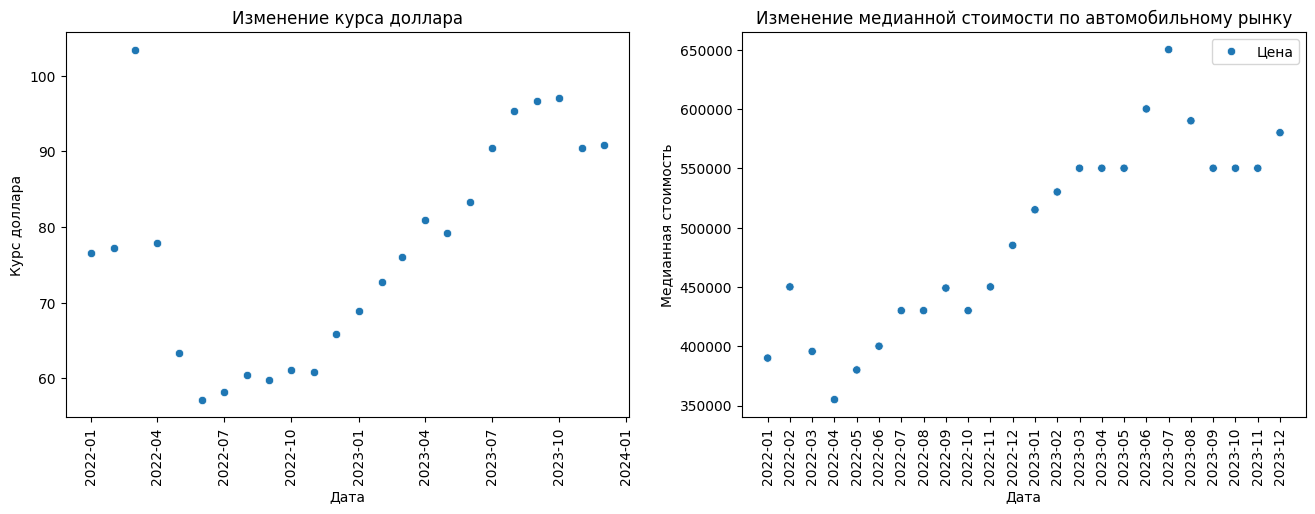

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(x= df_dol['new_date'], y= df_dol['Value'], ax=axes[0])
axes[0].set_title("Изменение курса доллара")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Курс доллара")
axes[0].tick_params(axis='x', rotation=90)

sns.scatterplot(
    df[df['Дата размещения объявления'].dt.year >= 2022]
    .groupby(df['new_date'])
    .agg({'Цена': 'median'}), 
    ax=axes[1]
)
axes[1].set_title("Изменение медианной стоимости по автомобильному рынку")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Медианная стоимость")
axes[1].tick_params(axis='x', rotation=90) 



Построим линию тренда для нахождения кореляции

Заметна кореляция между курсом доллара и стоимостью автомобилей. Это значит, что есть вероятность того, что идеальное время для покупки автомобиля можно отслеживать по курсу доллара

Заметим интересную тенденцию, что медианная цена по всему рынку растет не так стабильно, как цена на Ладу Приору. Пик приходится на июль 2023.

Тут стоит отметить, что я беру именно медианное значение, так как оно устойчиво к выбросам, в отличие от среднего. О наличии большого количества выбросов свидетельствует боксплот, приведенный ниже. Это связано с огромным количеством марок и моделей, а также продажей редких автомобилей.

Теперь узнаем конкурентов Лады Приоры (по ценовому сегменту)

In [23]:
segment = df_l['Цена'].median()
segment
standart = df_l['Цена'].std()
standart
minim, maxi = segment - standart, segment + standart

Возьмем только исправные машины, так как зачастую, цена неисправных автомобилей - выброс

In [24]:
df2 = df[df['Особые отметки'] == 'Нет']
df2 = df2.groupby(by = ['Название машины', 'Руль', 'Объем двигателя', 'Мощность', 'Привод']).agg({'Цена':'median', 'Название машины':'count', 'Год':'median', 'Пробег':'mean'})
df2 = df2[(df2['Цена'] >= minim) & (df2['Цена'] <= maxi)]

In [25]:
df2.rename({'Название машины': 'Количество объявлений'},axis=1, inplace=True)

In [26]:
df2.reset_index(inplace=True)

Сразу отбросим модели, число объявлений которых не превышает 10 тысяч экземпяров, так как появление таких объявлений - очень редкая ситуация

In [27]:
df2[(df2['Количество объявлений'] >= 7000)]

,Название машины,Руль,Объем двигателя,Мощность,Привод,Цена,Количество объявлений,Год,Пробег
1000,Chevrolet Lacetti,левый,1.4,95.0,передний,300000.0,7392,2009.0,160076.244311
1017,Chevrolet Lacetti,левый,1.6,109.0,передний,320000.0,11940,2007.0,167116.791544
1426,Ford Focus,левый,1.6,100.0,передний,330000.0,11449,2007.0,186177.620944
2012,Honda CR-V,правый,2.0,130.0,4WD,320000.0,16802,1996.0,249838.519108
2304,Honda Civic Ferio,правый,1.5,105.0,передний,235000.0,9000,2001.0,255757.341780
2381,Honda Fit,правый,1.3,86.0,передний,279000.0,30840,2002.0,222071.839927
2428,Honda HR-V,правый,1.6,105.0,передний,335000.0,10394,2000.0,227861.258544
2920,Hyundai Accent,левый,1.5,102.0,передний,245000.0,17563,2006.0,183304.247704
3091,Hyundai Getz,левый,1.4,97.0,передний,335000.0,11174,2008.0,134539.743433
6415,Peugeot 206,левый,1.4,75.0,передний,185000.0,8021,2007.0,159495.880563


Итого, у нас 16 конкурентов, которые попадают в ценовой сегмент Лады Приоры, а также количество объявлений о продаже превышает 10 тысяч

**Итог:** В ценовом диапазоне Лады Приоры мы имеем 2 полноприводных автомобиля, которые иедально подходят под определенные задачи. Также, стоит заметить, что большинство автомобилей гораздо старше, чем Лада Приора(за исключением отечествнных автомобилей). По мощности все автомбили находятся в +- одной категории, но Лада Приора, среди конкурентов имеет один из самых мощных моторов. Также видно, что, на удивление, средний пробег Лада Приора -  не самый маленький среди конкурентов.  
**Мое предложение:** В данном ценовом диапазоне я порекомендовал бы, помимо Лады Приоры, из отечественных автомобилей - Гранта, 2114. Из зарубежных - Renault Logan, Chevrolet Lacetti.

Для более полного анализа и выявления оптимальных моделей к покупке необходимо больше данных

Проведем анализ по регионам России, посмотрим, какие автомобили пользуются популярностью в разных регионах. Посмотрим количество продаж по регионам, выявим тренды и так далее. Продолжение можно посмотреть в файле analysis2.ipynb